In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import files
uploaded = files.upload()

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)
df.head()

Saving healthcare_operations_2023_2025.csv to healthcare_operations_2023_2025.csv


,Date,Day_of_Week,Month,Month_Name,Quarter,Week_of_Year,Is_Weekend,Holiday,Clinic_Type,Provider_Count,...,Cancelled_Appointments,No_Shows,Walk_Ins,Patient_Volume,Average_Wait_Time,Capacity_Utilization,Revenue,Claims_Submitted,Claims_Denied,Staffing_Level
0,2023-01-01,Sunday,1,January,1,52,1,0,General OPD,8,...,5,5,16,76,46.2,52.8,2505.17,72,3,13
1,2023-01-02,Monday,1,January,1,1,0,0,Surgical OPD,8,...,6,10,21,105,54.9,82.0,3211.62,102,6,14
2,2023-01-03,Tuesday,1,January,1,1,0,0,Medicine,8,...,7,9,27,136,80.6,100.0,4951.87,123,7,14
3,2023-01-04,Wednesday,1,January,1,1,0,0,Pediatrics,8,...,4,7,19,106,51.2,77.9,3756.94,98,4,10
4,2023-01-05,Thursday,1,January,1,1,0,0,General OPD,8,...,4,5,11,88,43.1,61.1,2740.15,80,5,14


In [3]:
df.shape

(1095, 23)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    1095 non-null   object 
 1   Day_of_Week             1095 non-null   object 
 2   Month                   1095 non-null   int64  
 3   Month_Name              1095 non-null   object 
 4   Quarter                 1095 non-null   int64  
 5   Week_of_Year            1095 non-null   int64  
 6   Is_Weekend              1095 non-null   int64  
 7   Holiday                 1095 non-null   int64  
 8   Clinic_Type             1095 non-null   object 
 9   Provider_Count          1095 non-null   int64  
 10  Available_Slots         1095 non-null   int64  
 11  Scheduled_Appointments  1095 non-null   int64  
 12  Completed_Appointments  1095 non-null   int64  
 13  Cancelled_Appointments  1095 non-null   int64  
 14  No_Shows                1095 non-null   

In [5]:
df.describe()

,Month,Quarter,Week_of_Year,Is_Weekend,Holiday,Provider_Count,Available_Slots,Scheduled_Appointments,Completed_Appointments,Cancelled_Appointments,No_Shows,Walk_Ins,Patient_Volume,Average_Wait_Time,Capacity_Utilization,Revenue,Claims_Submitted,Claims_Denied,Staffing_Level
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,6.516895,2.506849,26.476712,0.285845,0.010959,7.999087,131.997260,114.152511,116.694064,6.305936,8.137900,16.985388,116.694064,66.390137,89.242374,3735.359808,108.559817,6.597260,11.863927
std,3.448158,1.117297,15.053930,0.452022,0.104157,1.022149,19.260624,27.364316,26.006126,2.477045,2.681812,5.346475,26.006126,19.172409,21.407827,971.235383,24.494111,2.384707,1.699211
min,1.000000,1.000000,1.000000,0.000000,0.000000,5.000000,75.000000,33.000000,40.000000,1.000000,1.000000,2.000000,40.000000,21.200000,31.700000,1316.190000,37.000000,1.000000,8.000000
25%,4.000000,2.000000,13.000000,0.000000,0.000000,7.000000,119.500000,96.000000,98.000000,4.000000,6.000000,13.000000,98.000000,51.150000,73.600000,3018.125000,90.500000,5.000000,11.000000
50%,7.000000,3.000000,26.000000,0.000000,0.000000,8.000000,135.000000,116.000000,119.000000,6.000000,8.000000,17.000000,119.000000,62.000000,89.600000,3746.790000,111.000000,6.000000,12.000000
75%,10.000000,4.000000,39.500000,1.000000,0.000000,9.000000,144.000000,133.000000,135.000000,8.000000,10.000000,21.000000,135.000000,81.600000,105.550000,4359.495000,126.000000,8.000000,13.000000
max,12.000000,4.000000,52.000000,1.000000,1.000000,11.000000,198.000000,189.000000,188.000000,15.000000,19.000000,35.000000,188.000000,100.000000,125.000000,6787.950000,180.000000,15.000000,17.000000


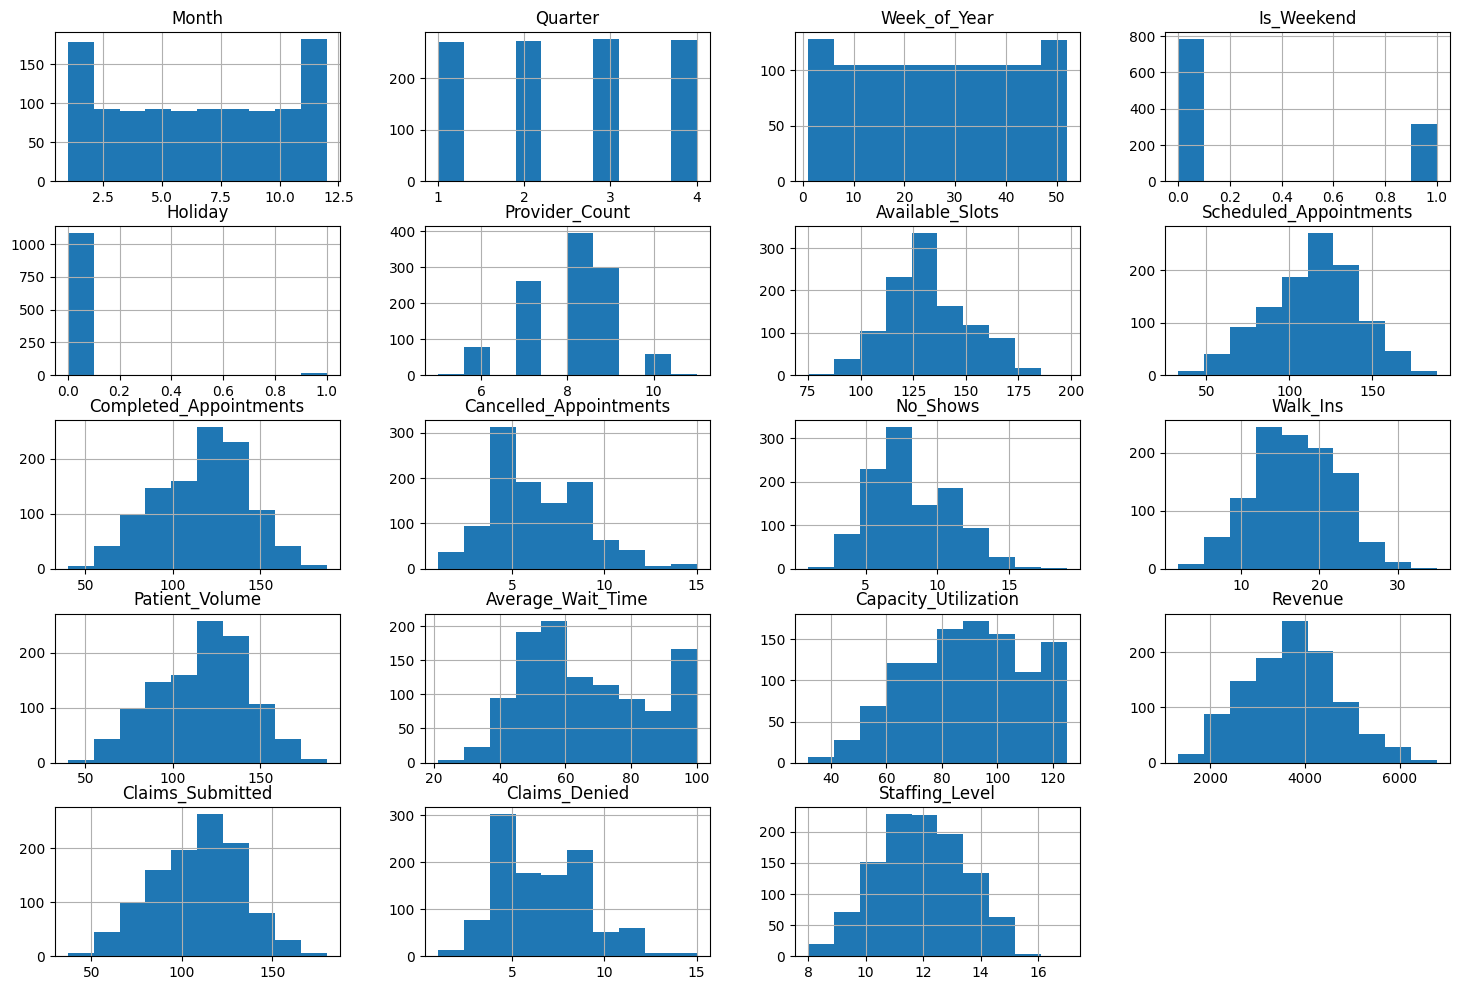

In [6]:
df.hist(figsize=(18,12))
import matplotlib.pyplot as plt
plt.show()

timeseries forecasting begin

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df = df.set_index("Date")

ts = df["Patient_Volume"]

print(ts.head())
print(ts.tail())
print(ts.isna().sum())

Date
2023-01-01     76
2023-01-02    105
2023-01-03    136
2023-01-04    106
2023-01-05     88
Name: Patient_Volume, dtype: int64
Date
2025-12-26     93
2025-12-27     68
2025-12-28    119
2025-12-29    146
2025-12-30    153
Name: Patient_Volume, dtype: int64
0


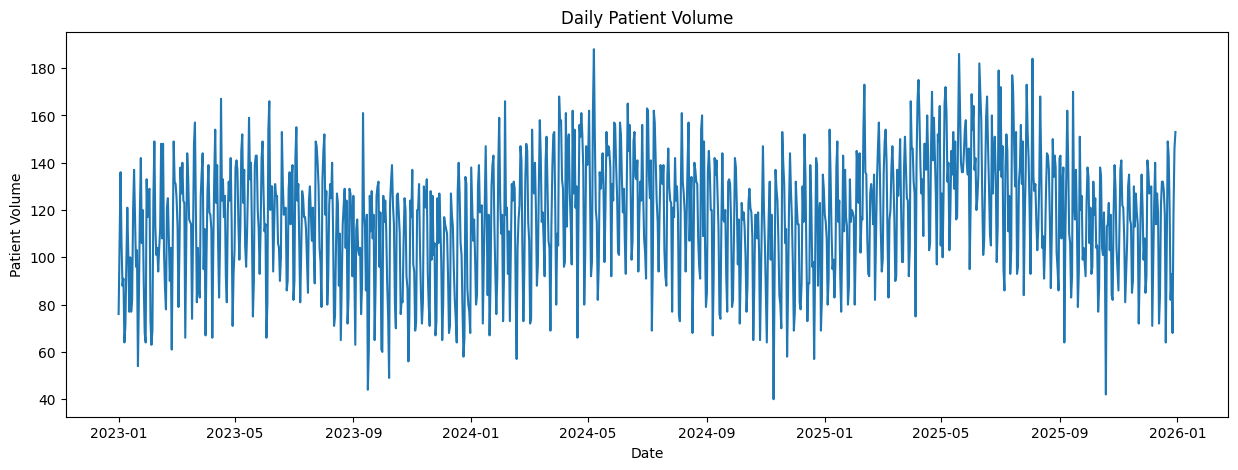

In [8]:
plt.figure(figsize=(15,5))

plt.plot(ts)

plt.title("Daily Patient Volume")
plt.xlabel("Date")
plt.ylabel("Patient Volume")

plt.show()

In [9]:
train_size = int(len(ts) * 0.80)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train:", len(train))
print("Test:", len(test))

Train: 876
Test: 219


In [10]:
naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index
)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

naive_mae = mean_absolute_error(test, naive_forecast)

naive_rmse = np.sqrt(
    mean_squared_error(test, naive_forecast)
)

naive_mape = np.mean(
    np.abs((test - naive_forecast) / test)
) * 100

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)
print("Naive MAPE:", naive_mape)

Naive MAE: 27.602739726027398
Naive RMSE: 34.034162262544996
Naive MAPE: 27.760794857617828


In [12]:
seasonal_values = np.resize(
    train.iloc[-7:].values,
    len(test)
)

seasonal_forecast = pd.Series(
    seasonal_values,
    index=test.index
)

In [13]:
seasonal_values = np.resize(
    train.iloc[-7:].values,
    len(test)
)

seasonal_forecast = pd.Series(
    seasonal_values,
    index=test.index
)

In [14]:
seasonal_naive_mae = mean_absolute_error(test, seasonal_forecast)

seasonal_naive_rmse = np.sqrt(
    mean_squared_error(test, seasonal_forecast)
)

seasonal_naive_mape = np.mean(
    np.abs((test - seasonal_forecast) / test)
) * 100

print("Seasonal Naive MAE:", seasonal_naive_mae)
print("Seasonal Naive RMSE:", seasonal_naive_rmse)
print("Seasonal Naive MAPE:", seasonal_naive_mape)

Seasonal Naive MAE: 31.840182648401825
Seasonal Naive RMSE: 37.000123410876505
Seasonal Naive MAPE: 30.504279761204998


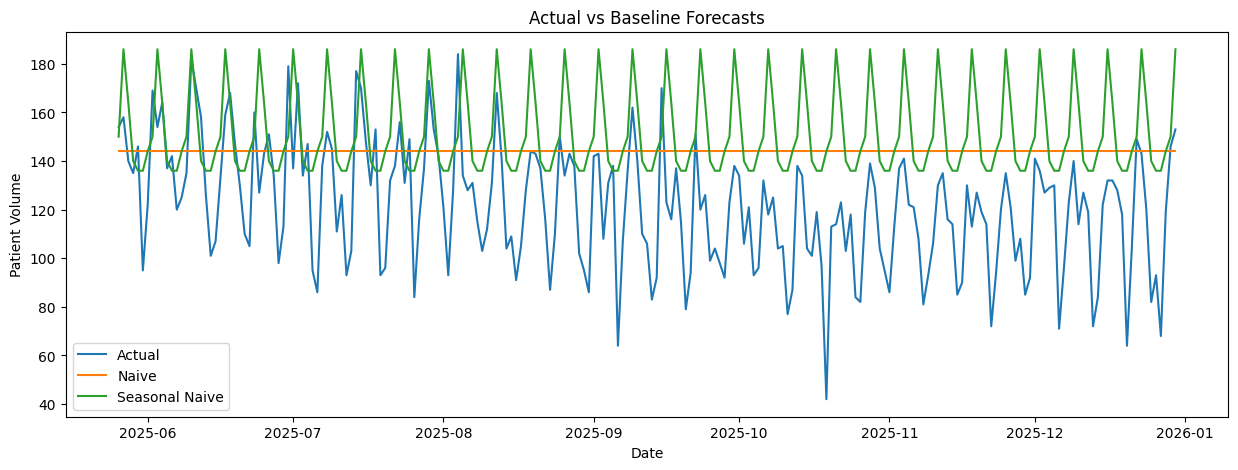

In [15]:
plt.figure(figsize=(15,5))

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, naive_forecast, label="Naive")
plt.plot(test.index, seasonal_forecast, label="Seasonal Naive")

plt.title("Actual vs Baseline Forecasts")
plt.xlabel("Date")
plt.ylabel("Patient Volume")

plt.legend()
plt.show()

arima

In [16]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fit ARIMA model
arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()

# Forecast for test period
arima_forecast = arima_fit.forecast(steps=len(test))

# Convert to Series with test index
arima_forecast = pd.Series(
    arima_forecast,
    index=test.index
)

# Evaluation
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = np.mean(
    np.abs((test - arima_forecast) / test)
) * 100

print("ARIMA Performance")
print("------------------")
print(f"MAE  : {arima_mae:.2f}")
print(f"RMSE : {arima_rmse:.2f}")
print(f"MAPE : {arima_mape:.2f}%")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA Performance
------------------
MAE  : 23.38
RMSE : 29.57
MAPE : 23.38%


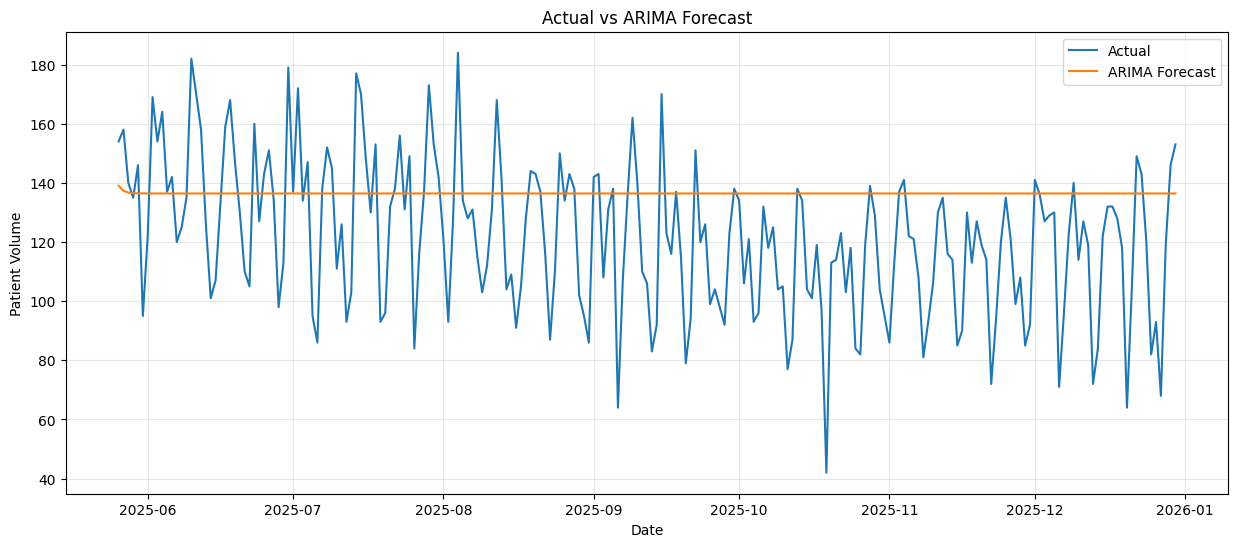

In [17]:
plt.figure(figsize=(15,6))

plt.plot(test.index, test,
         label='Actual')

plt.plot(test.index, arima_forecast,
         label='ARIMA Forecast')

plt.title('Actual vs ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Patient Volume')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

sarima

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

# Forecast
sarima_forecast = sarima_fit.forecast(
    steps=len(test)
)

sarima_forecast = pd.Series(
    sarima_forecast,
    index=test.index
)

# Evaluation
sarima_mae = mean_absolute_error(test, sarima_forecast)

sarima_rmse = np.sqrt(
    mean_squared_error(test, sarima_forecast)
)

sarima_mape = np.mean(
    np.abs((test - sarima_forecast) / test)
) * 100

print("SARIMA Performance")
print("------------------")
print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2f}%")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA Performance
------------------
MAE  : 31.03
RMSE : 35.39
MAPE : 28.89%


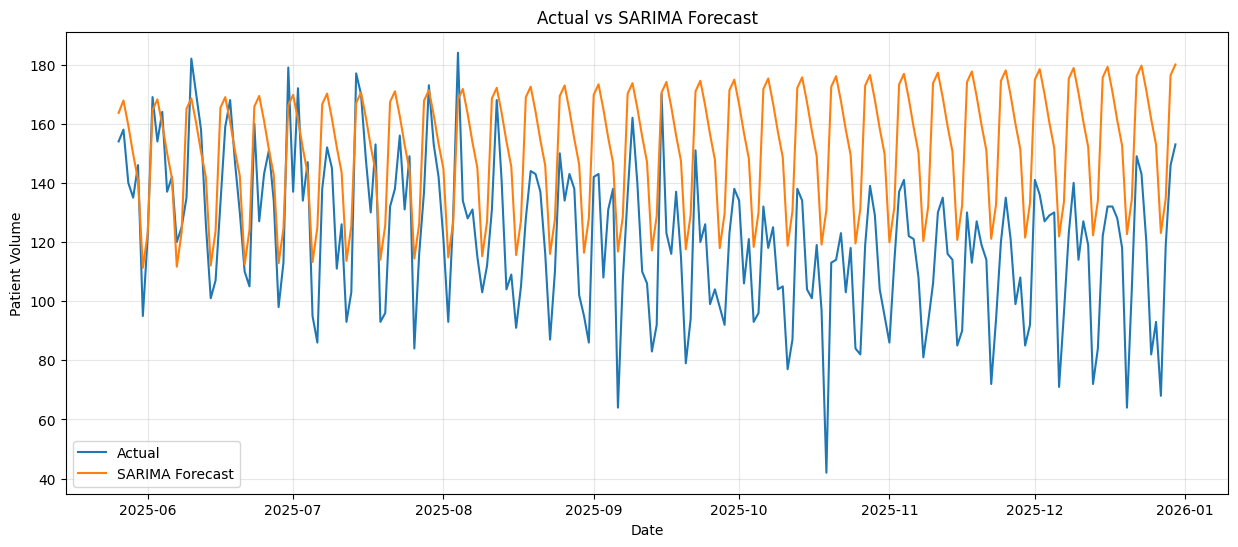

In [19]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    sarima_forecast,
    label='SARIMA Forecast'
)

plt.title('Actual vs SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Patient Volume')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

comparison

In [20]:
results = pd.DataFrame({
    'Model': [
        'Naive',
        'Seasonal Naive',
        'ARIMA',
        'SARIMA'
    ],

    'MAE': [
        naive_mae,
        seasonal_naive_mae,
        arima_mae,
        sarima_mae
    ],

    'RMSE': [
        naive_rmse,
        seasonal_naive_rmse,
        arima_rmse,
        sarima_rmse
    ],

    'MAPE (%)': [
        naive_mape,
        seasonal_naive_mape,
        arima_mape,
        sarima_mape
    ]
})

results = results.sort_values(
    by='RMSE'
).reset_index(drop=True)

results

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,23.383294,29.572368,23.380129
1,Naive,27.602740,34.034162,27.760795
2,SARIMA,31.030584,35.385368,28.886467
3,Seasonal Naive,31.840183,37.000123,30.504280


visual comparison

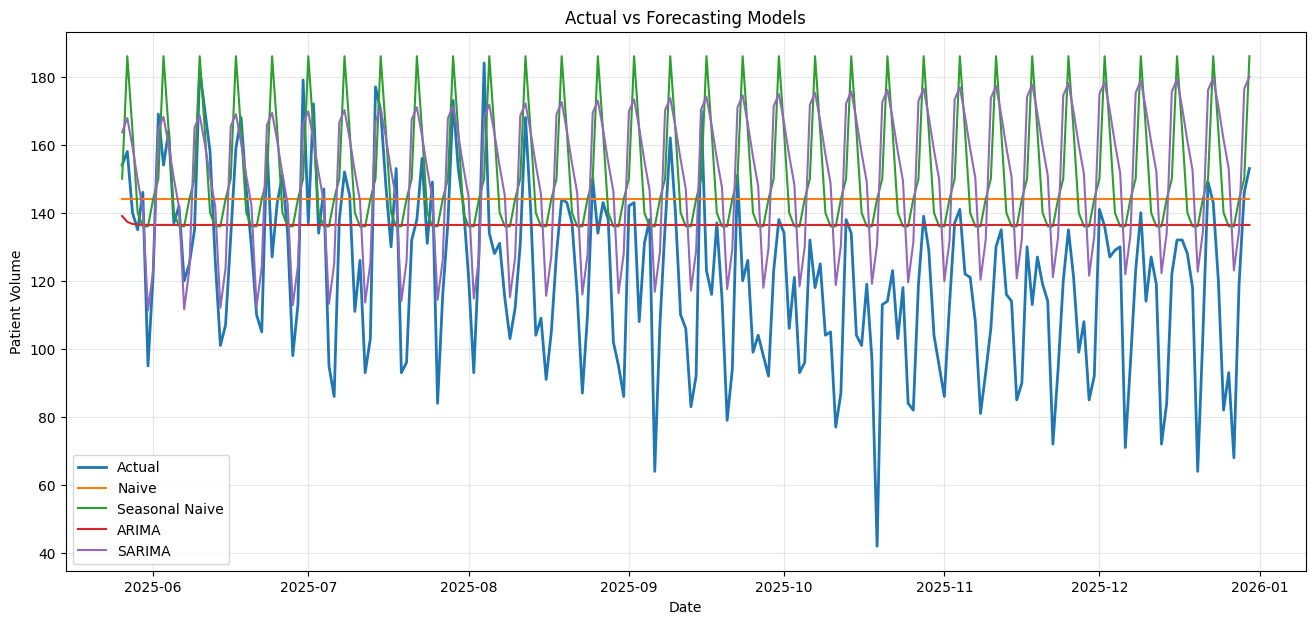

In [21]:
plt.figure(figsize=(16,7))

plt.plot(
    test.index,
    test,
    label='Actual',
    linewidth=2
)

plt.plot(
    test.index,
    naive_forecast,
    label='Naive'
)

plt.plot(
    test.index,
    seasonal_forecast,
    label='Seasonal Naive'
)

plt.plot(
    test.index,
    arima_forecast,
    label='ARIMA'
)

plt.plot(
    test.index,
    sarima_forecast,
    label='SARIMA'
)

plt.title('Actual vs Forecasting Models')
plt.xlabel('Date')
plt.ylabel('Patient Volume')
plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [22]:
best_model = results.loc[
    results['RMSE'].idxmin()
]

print("Best Model:")
print(best_model)

Best Model:
Model           ARIMA
MAE         23.383294
RMSE        29.572368
MAPE (%)    23.380129
Name: 0, dtype: object


In [23]:
print(
    f"The best-performing model based on RMSE is "
    f"{best_model['Model']}."
)

The best-performing model based on RMSE is ARIMA.


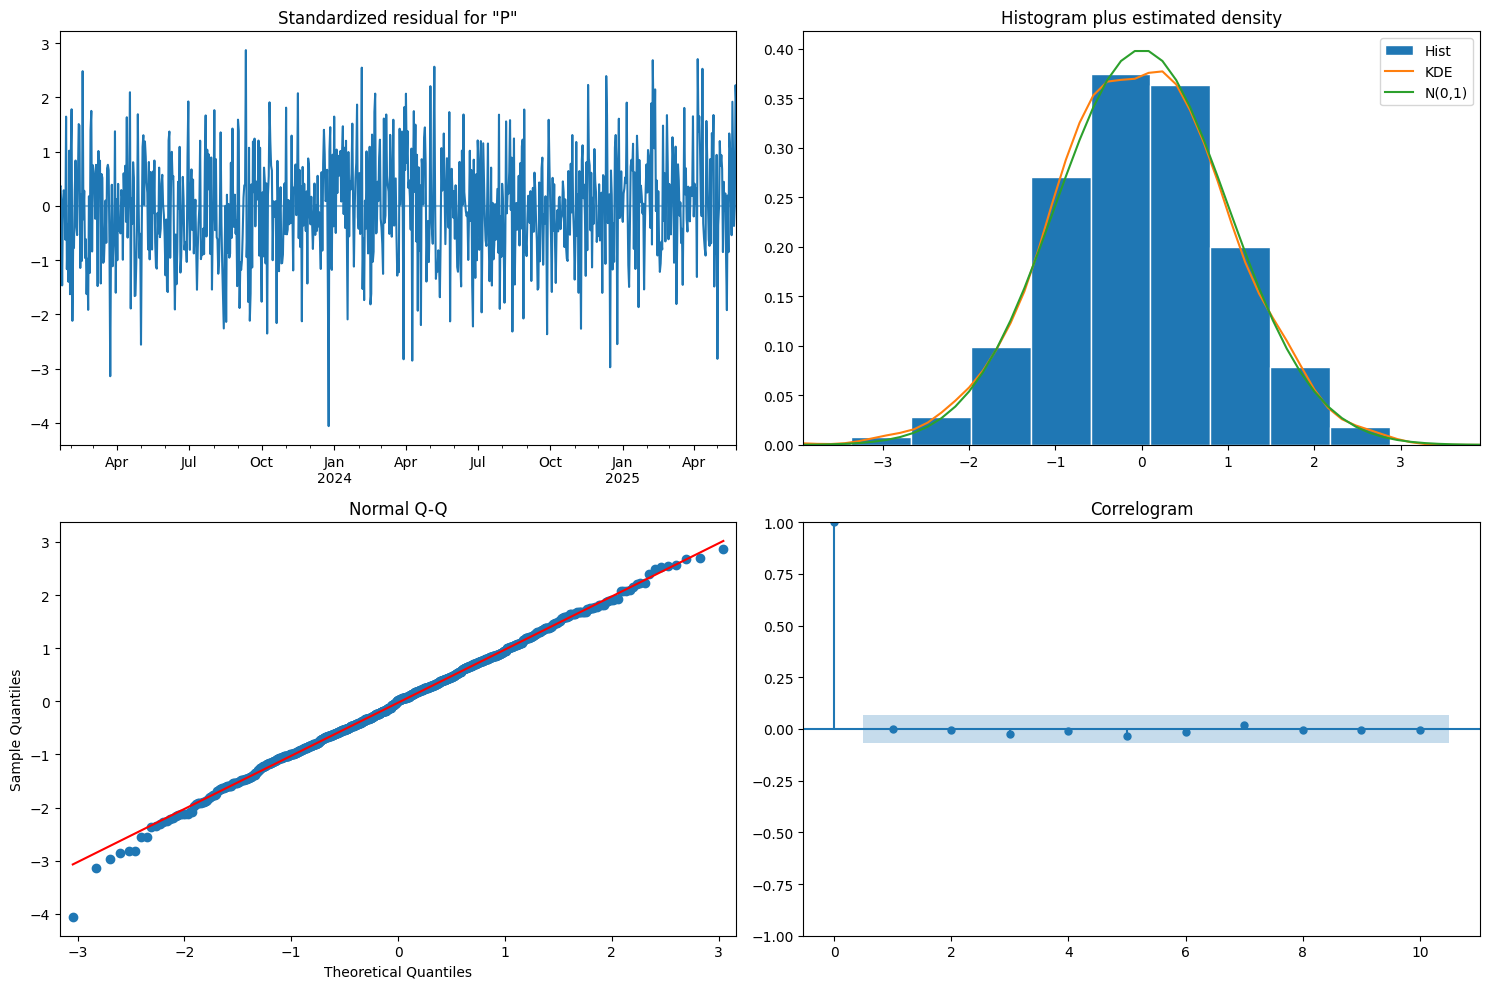

In [24]:
import matplotlib.pyplot as plt

sarima_fit.plot_diagnostics(figsize=(15,10))

plt.tight_layout()
plt.show()

In [25]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    sarima_fit.resid,
    lags=[7, 14, 21],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
7,5.276154,0.626303
14,7.293975,0.922784
21,10.262444,0.975299


In [26]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is stationary.")
else:
    print("Series is non-stationary.")

ADF Statistic: -1.0374273947614567
p-value: 0.7393700123205116
Series is non-stationary.


In [27]:
import warnings
warnings.filterwarnings("ignore")

sarima_orders = [
    ((1,1,1), (1,1,1,7)),
    ((1,1,0), (1,1,1,7)),
    ((0,1,1), (1,1,1,7)),
    ((1,1,1), (0,1,1,7)),
    ((0,1,1), (0,1,1,7))
]

sarima_results = []

for order, seasonal_order in sarima_orders:

    try:

        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        forecast = fitted.forecast(
            steps=len(test)
        )

        mae = mean_absolute_error(
            test,
            forecast
        )

        rmse = np.sqrt(
            mean_squared_error(
                test,
                forecast
            )
        )

        mape = np.mean(
            np.abs(
                (test - forecast) / test
            )
        ) * 100

        sarima_results.append({
            'Order': order,
            'Seasonal Order': seasonal_order,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE (%)': mape
        })

    except Exception as e:
        print("Model failed:", order, seasonal_order)

sarima_results_df = pd.DataFrame(
    sarima_results
)

sarima_results_df.sort_values(
    'RMSE'
).reset_index(drop=True)

,Order,Seasonal Order,MAE,RMSE,MAPE (%)
0,"(0, 1, 1)","(1, 1, 1, 7)",30.845957,35.191685,28.716903
1,"(0, 1, 1)","(0, 1, 1, 7)",30.847820,35.193867,28.718629
2,"(1, 1, 1)","(1, 1, 1, 7)",31.030584,35.385368,28.886467
3,"(1, 1, 1)","(0, 1, 1, 7)",31.031573,35.386582,28.887383
4,"(1, 1, 0)","(1, 1, 1, 7)",56.338098,59.900874,51.230309


In [28]:
best_sarima = sarima_results_df.loc[
    sarima_results_df['RMSE'].idxmin()
]

print("Best SARIMA Model")
print("------------------")
print(best_sarima)

Best SARIMA Model
------------------
Order                (0, 1, 1)
Seasonal Order    (1, 1, 1, 7)
MAE                  30.845957
RMSE                 35.191685
MAPE (%)             28.716903
Name: 2, dtype: object


In [29]:
best_order = best_sarima['Order']
best_seasonal_order = best_sarima['Seasonal Order']

print("Best Order:", best_order)
print("Best Seasonal Order:", best_seasonal_order)

Best Order: (0, 1, 1)
Best Seasonal Order: (1, 1, 1, 7)


In [30]:
final_sarima = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima.fit(
    disp=False
)

final_forecast = final_sarima_fit.forecast(
    steps=len(test)
)

final_forecast = pd.Series(
    final_forecast,
    index=test.index
)

In [31]:
final_mae = mean_absolute_error(
    test,
    final_forecast
)

final_rmse = np.sqrt(
    mean_squared_error(
        test,
        final_forecast
    )
)

final_mape = np.mean(
    np.abs(
        (test - final_forecast) / test
    )
) * 100

print("FINAL SARIMA PERFORMANCE")
print("-------------------------")
print(f"MAE  : {final_mae:.2f}")
print(f"RMSE : {final_rmse:.2f}")
print(f"MAPE : {final_mape:.2f}%")

FINAL SARIMA PERFORMANCE
-------------------------
MAE  : 30.85
RMSE : 35.19
MAPE : 28.72%


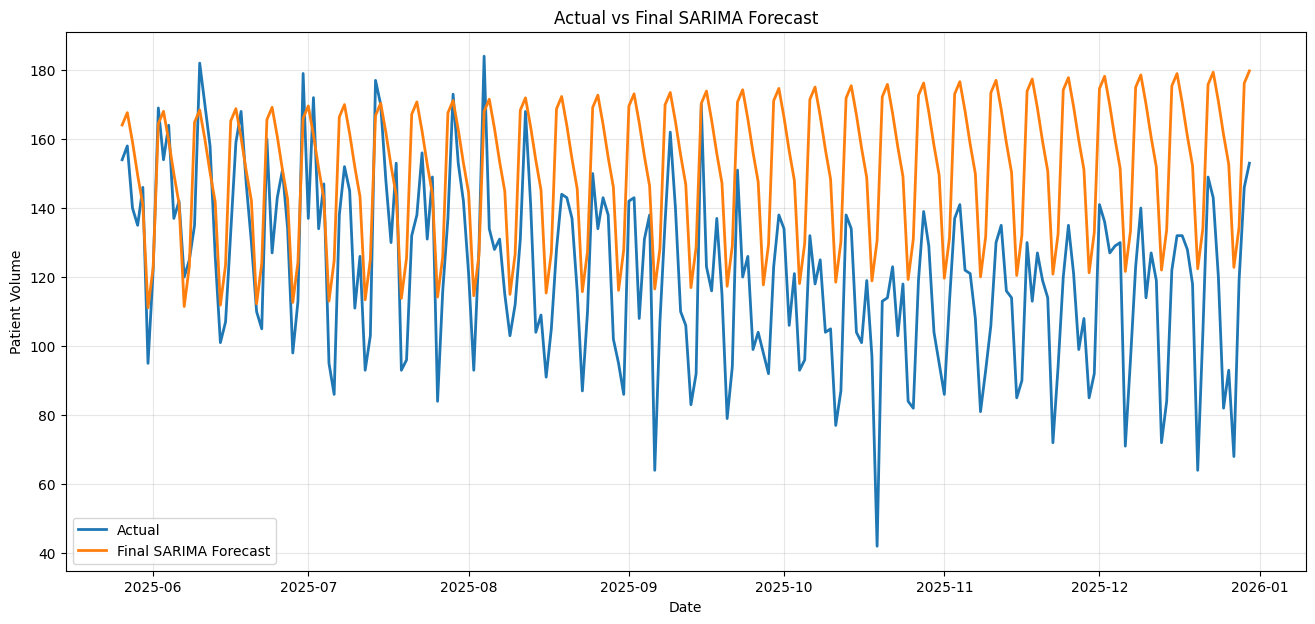

In [32]:
plt.figure(figsize=(16,7))

plt.plot(
    test.index,
    test,
    label='Actual',
    linewidth=2
)

plt.plot(
    test.index,
    final_forecast,
    label='Final SARIMA Forecast',
    linewidth=2
)

plt.title(
    'Actual vs Final SARIMA Forecast'
)

plt.xlabel('Date')
plt.ylabel('Patient Volume')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

RESOLVING LONG HORIZON FORECAST ISSUES TUNING SARIMA

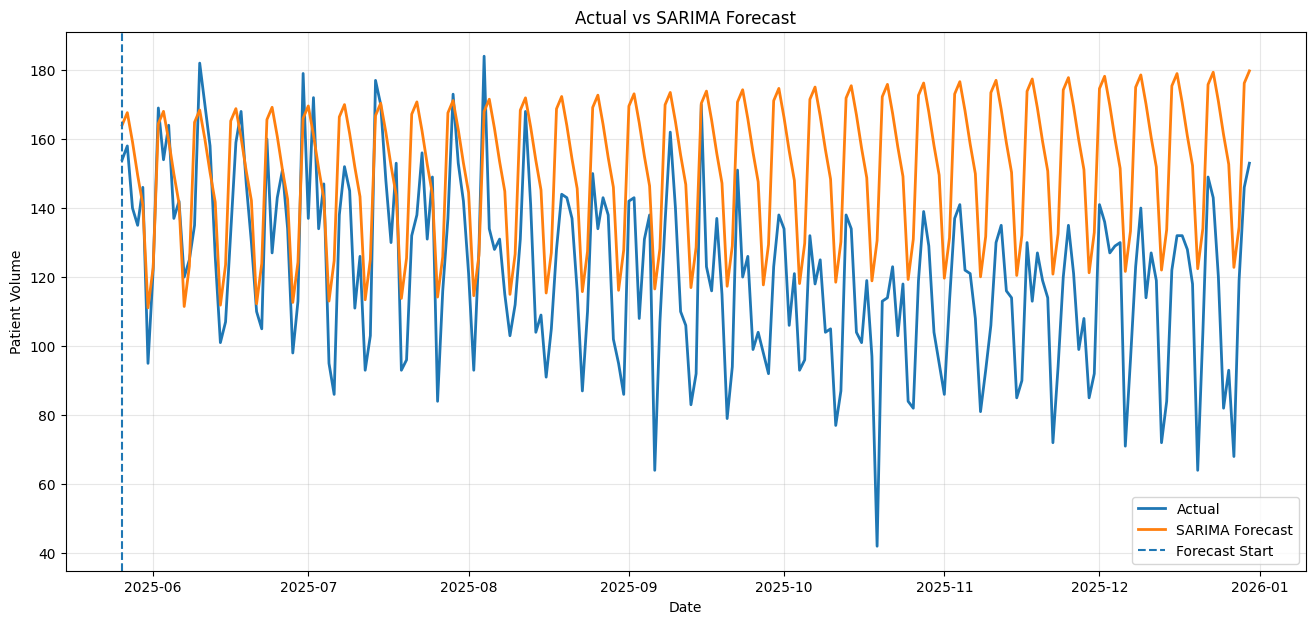

In [33]:
# ==========================================
# STEP 1: Check Final SARIMA Forecast
# ==========================================

plt.figure(figsize=(16,7))

plt.plot(
    test.index,
    test,
    label="Actual",
    linewidth=2
)

plt.plot(
    test.index,
    final_forecast,
    label="SARIMA Forecast",
    linewidth=2
)

# Mark where forecast starts
plt.axvline(
    test.index[0],
    linestyle="--",
    label="Forecast Start"
)

plt.title("Actual vs SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Patient Volume")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [34]:
# Show first and last 10 forecast values

comparison = pd.DataFrame({
    "Actual": test,
    "SARIMA_Forecast": final_forecast
})

print("FIRST 10 DAYS")
display(comparison.head(10))

print("\nLAST 10 DAYS")
display(comparison.tail(10))

FIRST 10 DAYS


,Actual,SARIMA_Forecast
Date,,
2025-05-26,154,164.058344
2025-05-27,158,167.642838
2025-05-28,140,159.211930
2025-05-29,135,149.524637
2025-05-30,146,140.950891
2025-05-31,95,111.093953
2025-06-01,122,122.771997
2025-06-02,169,164.456134
2025-06-03,154,168.024288



LAST 10 DAYS


,Actual,SARIMA_Forecast
Date,,
2025-12-21,104,134.097202
2025-12-22,149,175.792245
2025-12-23,143,179.360391
2025-12-24,120,170.936327
2025-12-25,82,161.256251
2025-12-26,93,152.680199
2025-12-27,68,122.808204
2025-12-28,119,134.488102
2025-12-29,146,176.183145


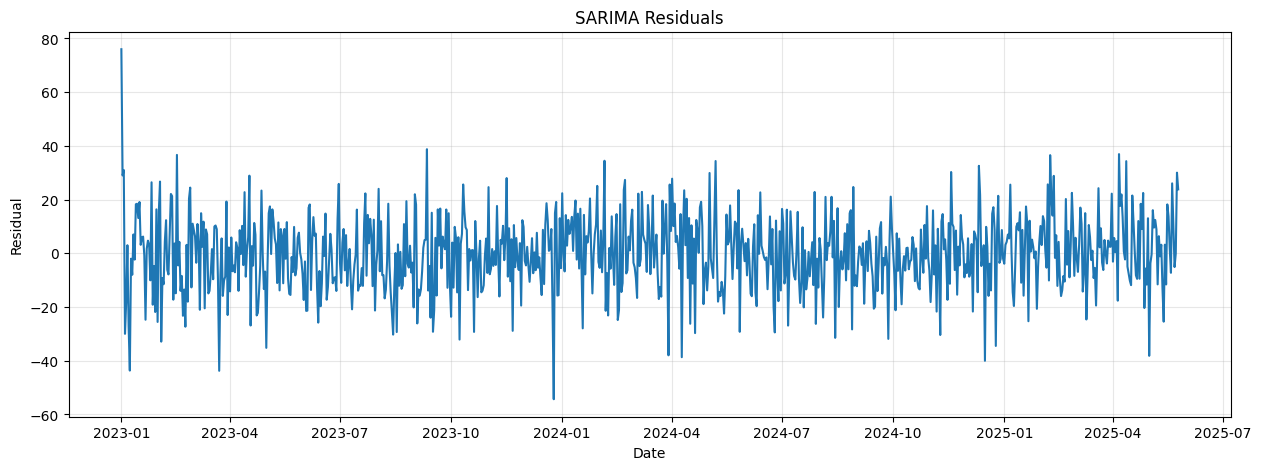

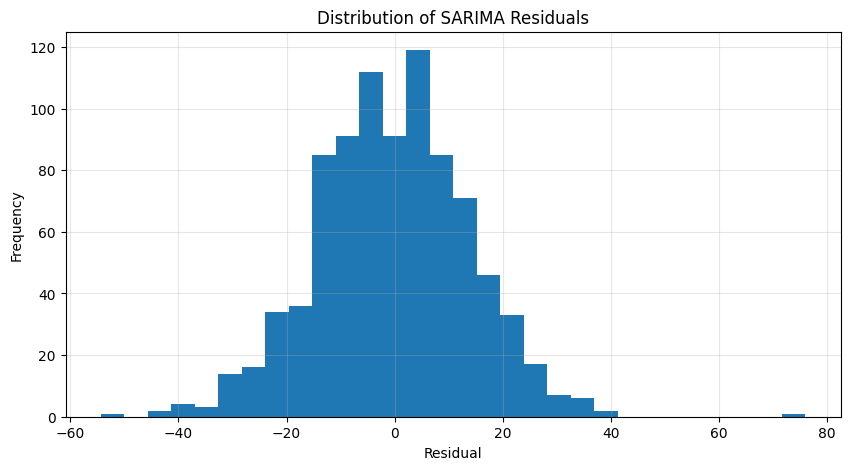

Ljung-Box Test:


,lb_stat,lb_pvalue
7,4.093794,0.768913
14,6.103719,0.963809
21,9.323174,0.986435
30,15.321283,0.987793


In [35]:
# ==========================================
# STEP 2: SARIMA RESIDUAL DIAGNOSTICS
# ==========================================

from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# Get residuals
residuals = final_sarima_fit.resid.dropna()

# Residual plot
plt.figure(figsize=(15, 5))
plt.plot(residuals)
plt.title("SARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.show()

# Residual histogram
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30)
plt.title("Distribution of SARIMA Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# Ljung-Box test
ljung_box = acorr_ljungbox(
    residuals,
    lags=[7, 14, 21, 30],
    return_df=True
)

print("Ljung-Box Test:")
display(ljung_box)

In [36]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = final_sarima_fit.resid.dropna()

ljung_box = acorr_ljungbox(
    residuals,
    lags=[7, 14, 21, 30],
    return_df=True
)

print("Ljung-Box Test:")
display(ljung_box)

Ljung-Box Test:


,lb_stat,lb_pvalue
7,4.093794,0.768913
14,6.103719,0.963809
21,9.323174,0.986435
30,15.321283,0.987793


In [37]:
# Compare actual vs SARIMA forecast on the test set

comparison = pd.DataFrame({
    "Actual": test,
    "SARIMA_Forecast": final_forecast
})

# Forecast error
comparison["Error"] = comparison["Actual"] - comparison["SARIMA_Forecast"]
comparison["Absolute_Error"] = comparison["Error"].abs()

print("First 10 predictions:")
display(comparison.head(10))

print("Last 10 predictions:")
display(comparison.tail(10))

print("\nFinal SARIMA Performance:")
print(f"MAE  : {mean_absolute_error(test, final_forecast):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(test, final_forecast)):.2f}")
print(f"MAPE : {np.mean(np.abs((test - final_forecast) / test)) * 100:.2f}%")

First 10 predictions:


,Actual,SARIMA_Forecast,Error,Absolute_Error
Date,,,,
2025-05-26,154,164.058344,-10.058344,10.058344
2025-05-27,158,167.642838,-9.642838,9.642838
2025-05-28,140,159.211930,-19.211930,19.211930
2025-05-29,135,149.524637,-14.524637,14.524637
2025-05-30,146,140.950891,5.049109,5.049109
2025-05-31,95,111.093953,-16.093953,16.093953
2025-06-01,122,122.771997,-0.771997,0.771997
2025-06-02,169,164.456134,4.543866,4.543866
2025-06-03,154,168.024288,-14.024288,14.024288


Last 10 predictions:


,Actual,SARIMA_Forecast,Error,Absolute_Error
Date,,,,
2025-12-21,104,134.097202,-30.097202,30.097202
2025-12-22,149,175.792245,-26.792245,26.792245
2025-12-23,143,179.360391,-36.360391,36.360391
2025-12-24,120,170.936327,-50.936327,50.936327
2025-12-25,82,161.256251,-79.256251,79.256251
2025-12-26,93,152.680199,-59.680199,59.680199
2025-12-27,68,122.808204,-54.808204,54.808204
2025-12-28,119,134.488102,-15.488102,15.488102
2025-12-29,146,176.183145,-30.183145,30.183145



Final SARIMA Performance:
MAE  : 30.85
RMSE : 35.19
MAPE : 28.72%


In [38]:
# Rolling / Updated SARIMA Forecast
# Model is updated after each actual observation

rolling_predictions = []
current_model = final_sarima_fit

for i in range(len(test)):

    # Forecast the next day
    next_forecast = current_model.forecast(steps=1)
    rolling_predictions.append(next_forecast.iloc[0])

    # Update model with the actual observed value
    current_model = current_model.extend(test.iloc[[i]])

# Convert predictions to Series
rolling_forecast = pd.Series(
    rolling_predictions,
    index=test.index
)

# Evaluate rolling forecast
rolling_mae = mean_absolute_error(test, rolling_forecast)
rolling_rmse = np.sqrt(mean_squared_error(test, rolling_forecast))
rolling_mape = np.mean(
    np.abs((test - rolling_forecast) / test)
) * 100

print("ROLLING SARIMA PERFORMANCE")
print(f"MAE  : {rolling_mae:.2f}")
print(f"RMSE : {rolling_rmse:.2f}")
print(f"MAPE : {rolling_mape:.2f}%")

ROLLING SARIMA PERFORMANCE
MAE  : 11.09
RMSE : 13.87
MAPE : 9.78%


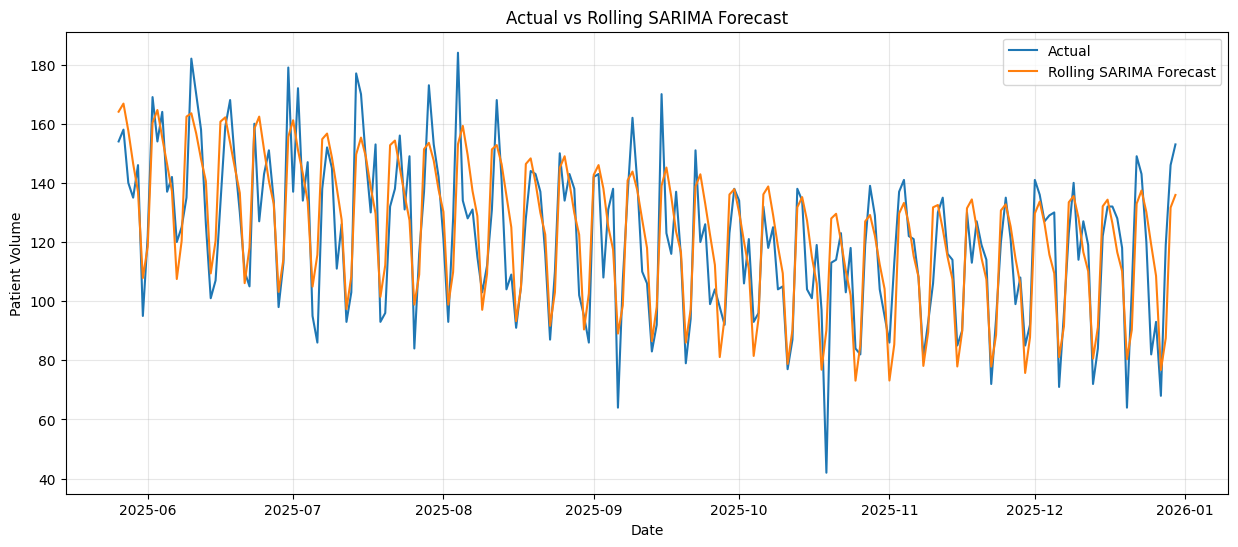

In [39]:
# Actual vs Rolling SARIMA Forecast

plt.figure(figsize=(15, 6))

plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, rolling_forecast.values, label="Rolling SARIMA Forecast")

plt.title("Actual vs Rolling SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Patient Volume")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [40]:
# Final Model Comparison

final_comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "ARIMA",
        "SARIMA",
        "Rolling SARIMA"
    ],
    "MAE": [
        naive_mae,
        seasonal_naive_mae,
        arima_mae,
        sarima_mae,
        rolling_mae
    ],
    "RMSE": [
        naive_rmse,
        seasonal_naive_rmse,
        arima_rmse,
        sarima_rmse,
        rolling_rmse
    ],
    "MAPE (%)": [
        naive_mape,
        seasonal_naive_mape,
        arima_mape,
        sarima_mape,
        rolling_mape
    ]
})

final_comparison = final_comparison.sort_values(
    by="RMSE"
).reset_index(drop=True)

display(final_comparison)

,Model,MAE,RMSE,MAPE (%)
0,Rolling SARIMA,11.090059,13.869215,9.776797
1,ARIMA,23.383294,29.572368,23.380129
2,Naive,27.602740,34.034162,27.760795
3,SARIMA,31.030584,35.385368,28.886467
4,Seasonal Naive,31.840183,37.000123,30.504280


In [41]:
# ==========================================
# STEP 6: FUTURE FORECAST USING FINAL SARIMA
# ==========================================

# Fit the selected SARIMA model on the complete dataset
final_model_full = SARIMAX(
    ts,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_model_full_fit = final_model_full.fit(disp=False)

# Forecast next 30 days
forecast_steps = 30

future_forecast = final_model_full_fit.forecast(
    steps=forecast_steps
)

# Create future dates
future_dates = pd.date_range(
    start=ts.index[-1] + pd.Timedelta(days=1),
    periods=forecast_steps,
    freq="D"
)

future_forecast = pd.Series(
    future_forecast.values,
    index=future_dates,
    name="Forecast"
)

print("NEXT 30 DAYS FORECAST")
display(future_forecast)

NEXT 30 DAYS FORECAST


,Forecast
2025-12-31,129.463237
2026-01-01,119.035166
2026-01-02,111.779842
2026-01-03,81.282043
2026-01-04,93.054610
2026-01-05,134.467608
2026-01-06,137.558414
2026-01-07,129.586769
2026-01-08,119.170010
2026-01-09,111.907196


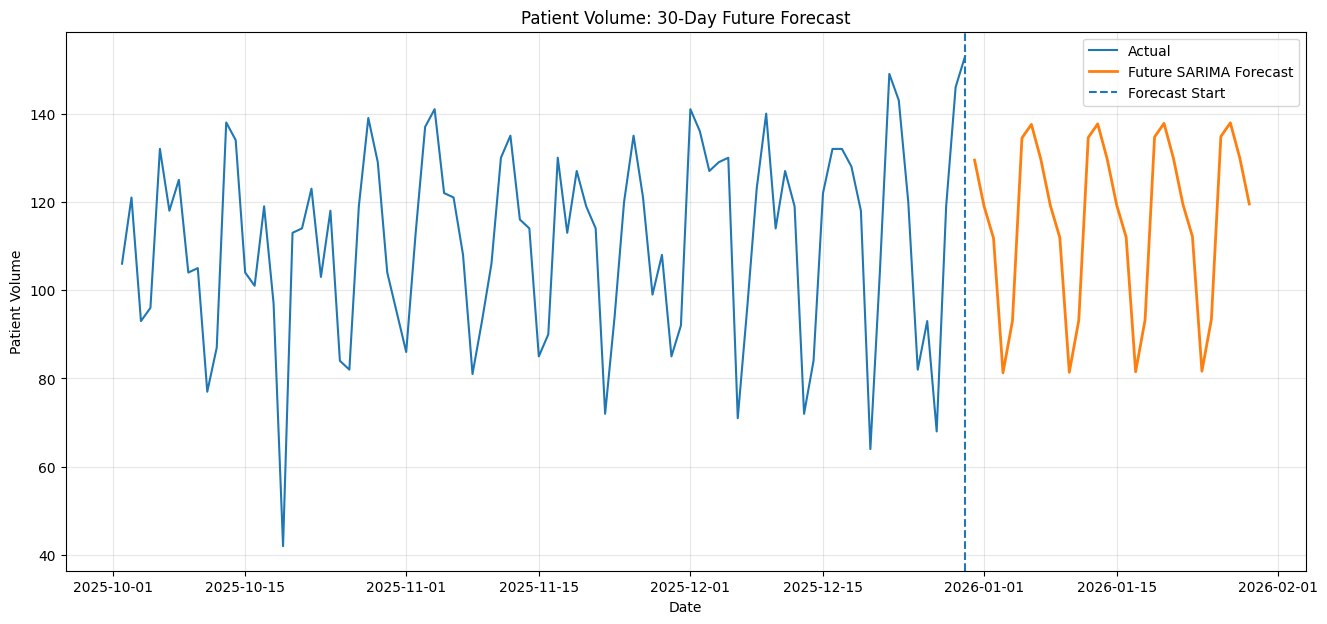

In [42]:
# ==========================================
# FUTURE FORECAST VISUALIZATION
# ==========================================

plt.figure(figsize=(16, 7))

# Last 90 days of actual data
plt.plot(
    ts.tail(90).index,
    ts.tail(90).values,
    label="Actual"
)

# Future forecast
plt.plot(
    future_forecast.index,
    future_forecast.values,
    label="Future SARIMA Forecast",
    linewidth=2
)

plt.axvline(
    ts.index[-1],
    linestyle="--",
    label="Forecast Start"
)

plt.title("Patient Volume: 30-Day Future Forecast")
plt.xlabel("Date")
plt.ylabel("Patient Volume")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [43]:
# ==========================================
# REUSABLE SARIMA FORECAST FUNCTION
# ==========================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import numpy as np


def sarima_forecast(data, date_col="Date",
                    target_col="Patient_Volume",
                    forecast_days=30):

    # Copy data
    data = data.copy()

    # Make sure date is datetime
    data[date_col] = pd.to_datetime(data[date_col])

    # Sort by date
    data = data.sort_values(date_col)

    # Create time series
    ts_new = data.set_index(date_col)[target_col].astype(float)

    # Remove missing values
    ts_new = ts_new.dropna()

    # Check minimum history
    if len(ts_new) < 30:
        raise ValueError(
            "At least 30 historical observations are recommended."
        )

    # Fit SARIMA using the selected orders
    model = SARIMAX(
        ts_new,
        order=best_order,
        seasonal_order=best_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(disp=False)

    # Forecast
    forecast = fitted_model.forecast(
        steps=forecast_days
    )

    # Future dates
    future_dates = pd.date_range(
        start=ts_new.index[-1] + pd.Timedelta(days=1),
        periods=forecast_days,
        freq="D"
    )

    # Create forecast dataframe
    forecast_df = pd.DataFrame({
        "Date": future_dates,
        "Forecast_Patient_Volume": forecast.values
    })

    return forecast_df

In [50]:
new_data = df.reset_index()[["Date", "Patient_Volume"]].copy()

new_forecast = sarima_forecast(
    new_data,
    forecast_days=30
)

display(new_forecast)

,Date,Forecast_Patient_Volume
0,2025-12-31,129.463237
1,2026-01-01,119.035166
2,2026-01-02,111.779842
3,2026-01-03,81.282043
4,2026-01-04,93.054610
5,2026-01-05,134.467608
6,2026-01-06,137.558414
7,2026-01-07,129.586769
8,2026-01-08,119.170010
9,2026-01-09,111.907196


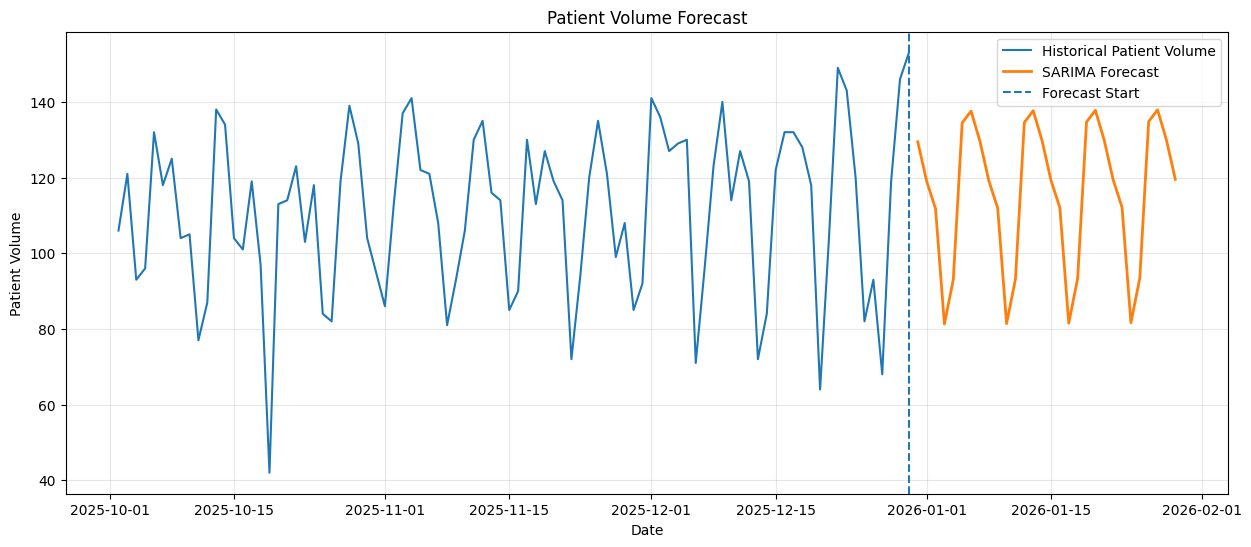

In [47]:
# ==========================================
# PLOT NEW DATA + FORECAST
# ==========================================

plt.figure(figsize=(15, 6))

plt.plot(
    new_data["Date"].tail(90),
    new_data["Patient_Volume"].tail(90),
    label="Historical Patient Volume"
)

plt.plot(
    new_forecast["Date"],
    new_forecast["Forecast_Patient_Volume"],
    label="SARIMA Forecast",
    linewidth=2
)

plt.axvline(
    new_data["Date"].max(),
    linestyle="--",
    label="Forecast Start"
)

plt.title("Patient Volume Forecast")
plt.xlabel("Date")
plt.ylabel("Patient Volume")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [48]:
# ==========================================
# REUSABLE ROLLING SARIMA FUNCTION
# ==========================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np


def rolling_sarima_forecast(
    data,
    date_col="Date",
    target_col="Patient_Volume",
    test_size=0.2,
    order=None,
    seasonal_order=None
):

    # Copy data
    data = data.copy()

    # Prepare dates
    data[date_col] = pd.to_datetime(data[date_col])
    data = data.sort_values(date_col)

    # Create time series
    ts_data = (
        data.set_index(date_col)[target_col]
        .astype(float)
        .dropna()
    )

    # Default to the best SARIMA orders already selected
    if order is None:
        order = best_order

    if seasonal_order is None:
        seasonal_order = best_seasonal_order

    # Train-test split
    split_point = int(len(ts_data) * (1 - test_size))

    train_data = ts_data.iloc[:split_point]
    test_data = ts_data.iloc[split_point:]

    # Initial SARIMA model
    model = SARIMAX(
        train_data,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(disp=False)

    # Rolling predictions
    predictions = []

    for i in range(len(test_data)):

        # Predict next observation
        forecast = fitted_model.forecast(steps=1)

        predictions.append(forecast.iloc[0])

        # Update model with actual observation
        fitted_model = fitted_model.extend(
            test_data.iloc[[i]]
        )

    # Convert predictions to Series
    predictions = pd.Series(
        predictions,
        index=test_data.index,
        name="Rolling_SARIMA_Forecast"
    )

    # Metrics
    mae = mean_absolute_error(
        test_data,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            test_data,
            predictions
        )
    )

    mape = np.mean(
        np.abs(
            (test_data - predictions) / test_data
        )
    ) * 100

    # Results dataframe
    results = pd.DataFrame({
        "Actual": test_data,
        "Forecast": predictions,
        "Error": test_data - predictions,
        "Absolute_Error": np.abs(test_data - predictions)
    })

    metrics = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

    return results, metrics

In [53]:
future_forecast = sarima_forecast(
    df.reset_index(), # Reset the index so 'Date' is a column again
    date_col="Date",
    target_col="Patient_Volume",
    forecast_days=30 # Use forecast_days for future forecasting
)

# The sarima_forecast function returns a DataFrame directly.
display(future_forecast)

,Date,Forecast_Patient_Volume
0,2025-12-31,129.463237
1,2026-01-01,119.035166
2,2026-01-02,111.779842
3,2026-01-03,81.282043
4,2026-01-04,93.054610
5,2026-01-05,134.467608
6,2026-01-06,137.558414
7,2026-01-07,129.586769
8,2026-01-08,119.170010
9,2026-01-09,111.907196


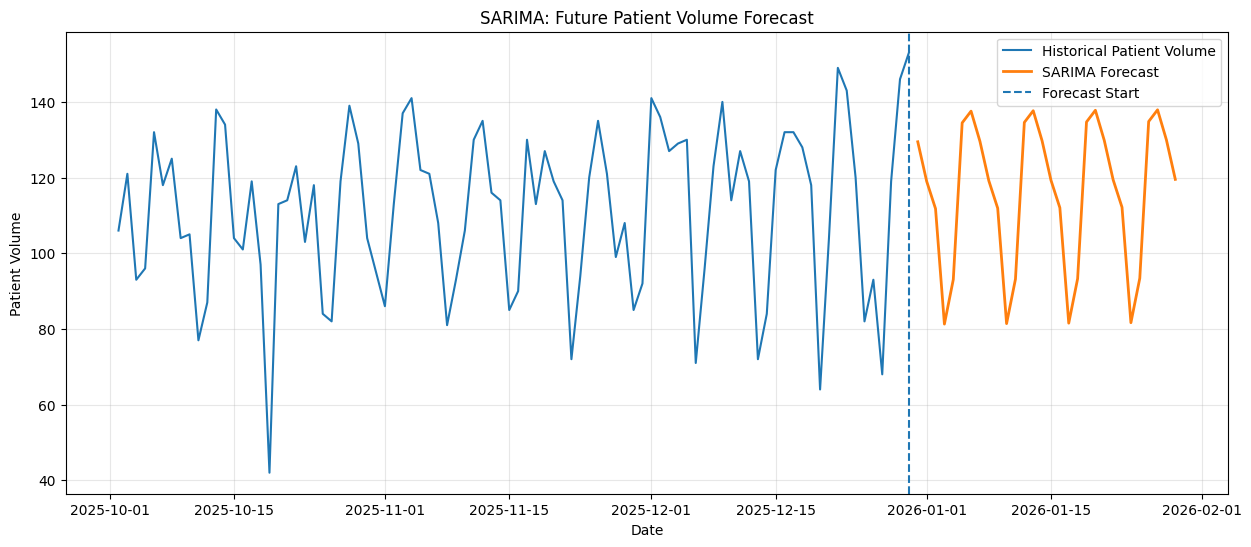

In [56]:
# ==========================================
# FUTURE SARIMA FORECAST VISUALIZATION
# ==========================================

plt.figure(figsize=(15, 6))

plt.plot(
    df.index[-90:], # Corrected to use df.index slicing
    df["Patient_Volume"].tail(90),
    label="Historical Patient Volume"
)

plt.plot(
    future_forecast["Date"],
    future_forecast["Forecast_Patient_Volume"],
    label="SARIMA Forecast", # Updated label
    linewidth=2
)

plt.axvline(
    df.index.max(), # Corrected to use df.index
    linestyle="--",
    label="Forecast Start"
)

plt.title("SARIMA: Future Patient Volume Forecast") # Updated title
plt.xlabel("Date")
plt.ylabel("Patient Volume")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

final checks

In [57]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def multi_step_rolling_sarima(
    data,
    date_col="Date",
    target_col="Patient_Volume",
    horizon=30,
    test_size=0.2,
    order=None,
    seasonal_order=None
):

    data = data.copy()
    data[date_col] = pd.to_datetime(data[date_col])
    data = data.sort_values(date_col)

    ts = (
        data.set_index(date_col)[target_col]
        .astype(float)
        .dropna()
    )

    if order is None:
        order = best_order

    if seasonal_order is None:
        seasonal_order = best_seasonal_order

    split_point = int(len(ts) * (1 - test_size))

    train = ts.iloc[:split_point]
    test = ts.iloc[split_point:]

    forecasts = []
    actuals = []
    forecast_dates = []

    # Start points inside the test period
    for start in range(0, len(test), horizon):

        history_end = split_point + start
        history = ts.iloc[:history_end]

        remaining = len(test) - start
        steps = min(horizon, remaining)

        model = SARIMAX(
            history,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        forecast = fitted.forecast(steps=steps)

        actual = test.iloc[start:start + steps]

        forecasts.extend(forecast.values)
        actuals.extend(actual.values)
        forecast_dates.extend(actual.index)

    forecasts = pd.Series(
        forecasts,
        index=forecast_dates,
        name="Forecast"
    )

    actuals = pd.Series(
        actuals,
        index=forecast_dates,
        name="Actual"
    )

    mae = mean_absolute_error(actuals, forecasts)
    rmse = np.sqrt(mean_squared_error(actuals, forecasts))
    mape = np.mean(
        np.abs((actuals - forecasts) / actuals)
    ) * 100

    results = pd.DataFrame({
        "Actual": actuals,
        "Forecast": forecasts
    })

    results["Error"] = results["Actual"] - results["Forecast"]
    results["Absolute_Error"] = np.abs(results["Error"])

    metrics = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

    return results, metrics

In [59]:
multi_results, multi_metrics = multi_step_rolling_sarima(
    df.reset_index(), # Reset the index so 'Date' is a column again
    date_col="Date",
    target_col="Patient_Volume",
    horizon=30,
    test_size=0.2
)

print("30-Day Rolling SARIMA Performance")
print("----------------------------------")
print(f"MAE  : {multi_metrics['MAE']:.2f}")
print(f"RMSE : {multi_metrics['RMSE']:.2f}")
print(f"MAPE : {multi_metrics['MAPE (%)']:.2f}%")

30-Day Rolling SARIMA Performance
----------------------------------
MAE  : 12.11
RMSE : 14.88
MAPE : 10.85%


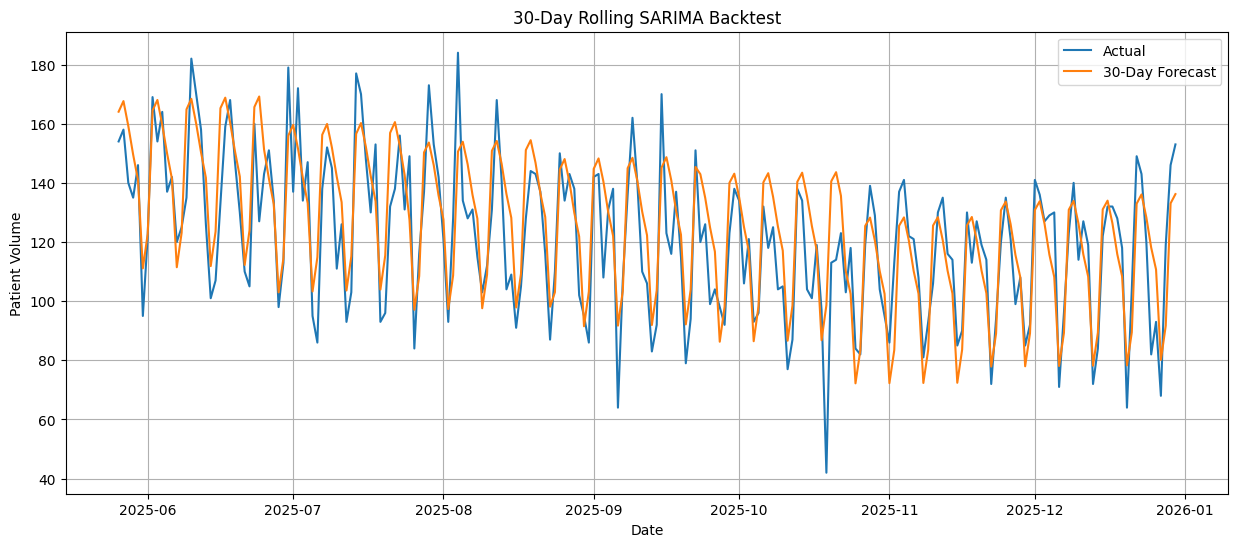

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    multi_results.index,
    multi_results["Actual"],
    label="Actual"
)

plt.plot(
    multi_results.index,
    multi_results["Forecast"],
    label="30-Day Forecast"
)

plt.title("30-Day Rolling SARIMA Backtest")
plt.xlabel("Date")
plt.ylabel("Patient Volume")
plt.legend()
plt.grid(True)

plt.show()

csv validation prior to forecast

In [61]:
import pandas as pd
import numpy as np

def validate_forecasting_data(
    data,
    date_col="Date",
    target_col="Patient_Volume",
    min_days=90
):

    df_check = data.copy()
    problems = []
    warnings = []

    # -----------------------------
    # 1. Required columns
    # -----------------------------
    if date_col not in df_check.columns:
        problems.append(f"Missing required column: {date_col}")

    if target_col not in df_check.columns:
        problems.append(f"Missing required column: {target_col}")

    if problems:
        return {
            "valid": False,
            "problems": problems,
            "warnings": warnings
        }

    # -----------------------------
    # 2. Convert Date
    # -----------------------------
    df_check[date_col] = pd.to_datetime(
        df_check[date_col],
        errors="coerce"
    )

    invalid_dates = df_check[date_col].isna().sum()

    if invalid_dates > 0:
        problems.append(
            f"{invalid_dates} invalid or missing dates found."
        )

    # -----------------------------
    # 3. Convert target to numeric
    # -----------------------------
    df_check[target_col] = pd.to_numeric(
        df_check[target_col],
        errors="coerce"
    )

    missing_target = df_check[target_col].isna().sum()

    if missing_target > 0:
        problems.append(
            f"{missing_target} missing/non-numeric "
            f"{target_col} values found."
        )

    # -----------------------------
    # Stop if dates are invalid
    # -----------------------------
    if df_check[date_col].isna().any():
        return {
            "valid": False,
            "problems": problems,
            "warnings": warnings
        }

    # -----------------------------
    # 4. Sort dates
    # -----------------------------
    df_check = df_check.sort_values(date_col)

    # -----------------------------
    # 5. Duplicate dates
    # -----------------------------
    duplicate_dates = df_check[date_col].duplicated().sum()

    if duplicate_dates > 0:
        problems.append(
            f"{duplicate_dates} duplicate dates found."
        )

    # -----------------------------
    # 6. Negative patient volume
    # -----------------------------
    negative_values = (
        df_check[target_col].dropna() < 0
    ).sum()

    if negative_values > 0:
        problems.append(
            f"{negative_values} negative "
            f"{target_col} values found."
        )

    # -----------------------------
    # 7. Number of observations
    # -----------------------------
    n = len(df_check)

    if n < min_days:
        problems.append(
            f"Only {n} observations found. "
            f"At least {min_days} observations are recommended."
        )

    # -----------------------------
    # 8. Date range
    # -----------------------------
    start_date = df_check[date_col].min()
    end_date = df_check[date_col].max()

    # -----------------------------
    # 9. Missing dates
    # -----------------------------
    expected_dates = pd.date_range(
        start=start_date,
        end=end_date,
        freq="D"
    )

    actual_dates = pd.DatetimeIndex(
        df_check[date_col].drop_duplicates()
    )

    missing_dates = expected_dates.difference(actual_dates)

    if len(missing_dates) > 0:
        warnings.append(
            f"{len(missing_dates)} missing calendar dates found."
        )

    # -----------------------------
    # 10. Very low variation
    # -----------------------------
    if df_check[target_col].nunique(dropna=True) <= 1:
        problems.append(
            f"{target_col} has no meaningful variation."
        )

    # -----------------------------
    # Final result
    # -----------------------------
    valid = len(problems) == 0

    return {
        "valid": valid,
        "observations": n,
        "start_date": start_date,
        "end_date": end_date,
        "problems": problems,
        "warnings": warnings
    }

In [62]:
validation = validate_forecasting_data(
    df,
    date_col="Date",
    target_col="Patient_Volume"
)

print("DATA VALIDATION")
print("================")

print("Valid:", validation["valid"])
print("Observations:", validation.get("observations"))
print("Start Date:", validation.get("start_date"))
print("End Date:", validation.get("end_date"))

print("\nProblems:")
if validation["problems"]:
    for p in validation["problems"]:
        print("❌", p)
else:
    print("✅ No critical problems found.")

print("\nWarnings:")
if validation["warnings"]:
    for w in validation["warnings"]:
        print("⚠️", w)
else:
    print("✅ No warnings.")

DATA VALIDATION
Valid: False
Observations: None
Start Date: None
End Date: None

Problems:
❌ Missing required column: Date

Warnings:
✅ No warnings.


In [63]:
print("VALIDATION RESULT")
print("=================")

print("Valid:", validation["valid"])

print("\n❌ PROBLEMS:")
for p in validation["problems"]:
    print("-", p)

print("\n⚠️ WARNINGS:")
for w in validation["warnings"]:
    print("-", w)

VALIDATION RESULT
Valid: False

❌ PROBLEMS:
- Missing required column: Date

⚠️ WARNINGS:


In [64]:
validation = validate_forecasting_data(
    df.reset_index(),
    date_col="Date",
    target_col="Patient_Volume"
)

print("VALIDATION RESULT")
print("=================")

print("Valid:", validation["valid"])
print("Observations:", validation.get("observations"))
print("Start Date:", validation.get("start_date"))
print("End Date:", validation.get("end_date"))

print("\n❌ PROBLEMS:")
if validation["problems"]:
    for p in validation["problems"]:
        print("-", p)
else:
    print("None")

print("\n⚠️ WARNINGS:")
if validation["warnings"]:
    for w in validation["warnings"]:
        print("-", w)
else:
    print("None")

VALIDATION RESULT
Valid: True
Observations: 1095
Start Date: 2023-01-01 00:00:00
End Date: 2025-12-30 00:00:00

❌ PROBLEMS:
None

⚠️ WARNINGS:
None
